# Advanced Manifold Learning

Manifold learning techniques aim to reduce high-dimensional data to a lower-dimensional space while preserving meaningful structure — particularly when the data lies on a nonlinear manifold. Isomap which was introduced in the previous part was one of the manifold learning techniques. These methods go beyond linear techniques like PCA by maintaining local geometry or geodesic distances. In this section, we focus on:

- Locally Linear Embedding (LLE)
- Laplacian Eigenmaps

### Locally Linear Embedding (LLE)
LLE assumes that each data point and its neighbors lie on a locally linear patch of the manifold. It learns the low-dimensional embedding that best preserves these local relationships.

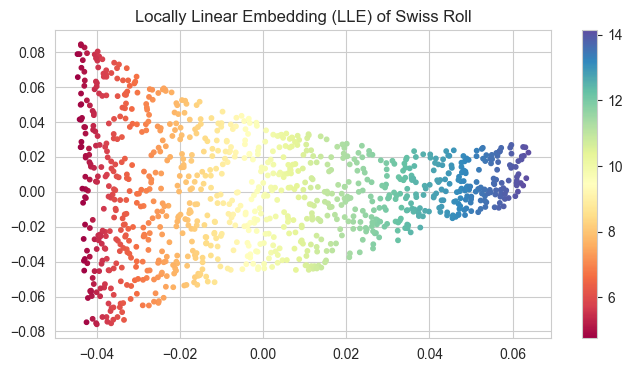

In [3]:
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import LocallyLinearEmbedding
import matplotlib.pyplot as plt

X, color = make_swiss_roll(n_samples=1000, noise=0.05, random_state=42)

lle = LocallyLinearEmbedding(n_neighbors=12, n_components=2, method='standard')
X_lle = lle.fit_transform(X)

plt.figure(figsize=(8, 4))
plt.scatter(X_lle[:, 0], X_lle[:, 1], c=color, cmap='Spectral', s=10)
plt.title("Locally Linear Embedding (LLE) of Swiss Roll")
plt.colorbar()
plt.show()

### Laplacian Eigenmaps

Laplacian Eigenmaps is a spectral technique that uses graph Laplacians to preserve local neighborhood relationships. It’s particularly effective when the data forms a continuous manifold and works similarly to LLE, but with a stronger graph-theoretic foundation.

<function matplotlib.pyplot.show(close=None, block=None)>

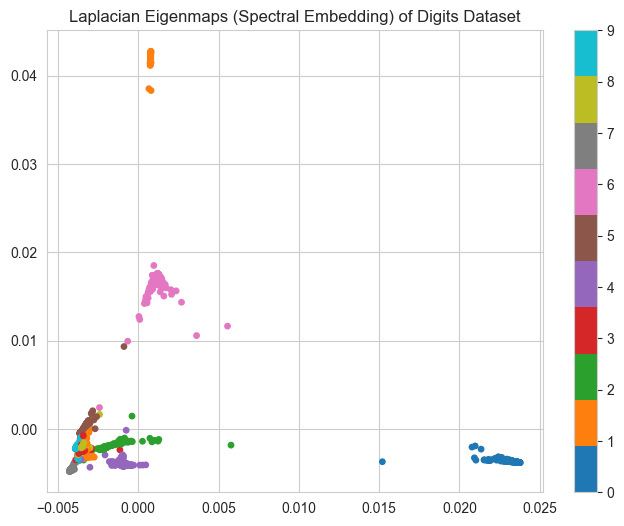

In [5]:
from sklearn.datasets import load_digits
from sklearn.manifold import SpectralEmbedding
import matplotlib.pyplot as plt

digits = load_digits()
X = digits.data
y = digits.target

spectral = SpectralEmbedding(n_components=2, n_neighbors=10)
X_spec = spectral.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_spec[:, 0], X_spec[:, 1], c=y, cmap='tab10', s=15)
plt.title("Laplacian Eigenmaps (Spectral Embedding) of Digits Dataset")
plt.colorbar()
plt.show

### Spectral clustering

Spectral Clustering is a graph-based clustering method that excels at detecting complex, non-convex cluster structures that traditional algorithms like K-Means struggle with. Instead of relying on direct distances between points, spectral clustering transforms the data into a graph and uses the eigenvectors of a graph Laplacian to find clusters.

The core idea is:

- Construct a similarity graph from the data (usually based on k-nearest neighbors or a Gaussian kernel).
- Compute the Laplacian of this graph.
- Extract a low-dimensional embedding using the eigenvectors of the Laplacian.
- Run K-Means on the resulting embedding to assign clusters.


This method can identify clusters that are connected but not necessarily globular or linearly separable.

/Users/guywinfield/PycharmProjects/.turing_venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


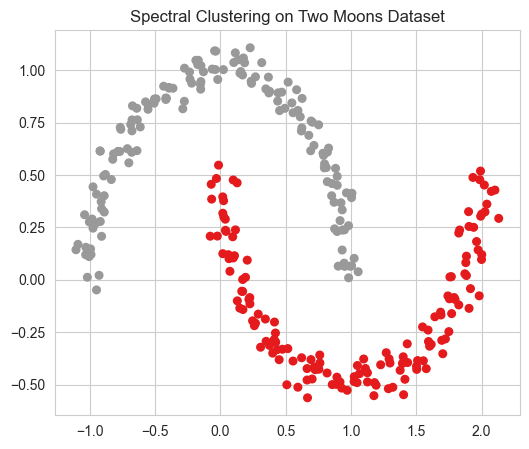

In [7]:
from sklearn.datasets import make_moons
from sklearn.cluster import SpectralClustering
import matplotlib.pyplot as plt

X, y = make_moons(n_samples=300, noise=0.05, random_state=42)

sc = SpectralClustering(n_clusters=2, affinity='nearest_neighbors',
					n_neighbors=10, assign_labels='kmeans', random_state=42)
labels = sc.fit_predict(X)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='Set1', s=30)
plt.title("Spectral Clustering on Two Moons Dataset")
plt.show()

Alternate Affinity: RBF (Gaussian) Kernel. You can also use a Gaussian similarity matrix instead of nearest neighbors:

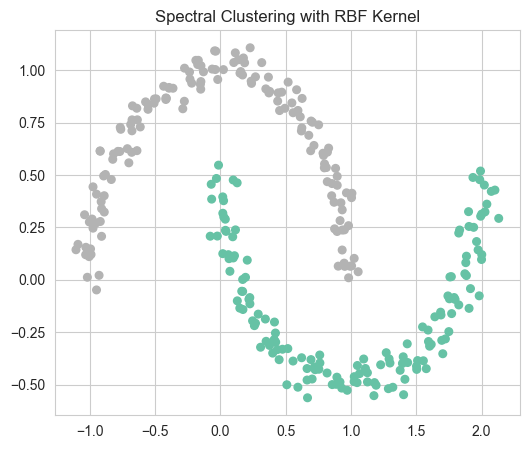

In [9]:
sc_rbf = SpectralClustering(n_clusters=2, affinity='rbf',
									gamma=15, assign_labels='kmeans', random_state=42)
labels_rbf = sc_rbf.fit_predict(X)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels_rbf, cmap='Set2', s=30)
plt.title("Spectral Clustering with RBF Kernel")
plt.show()

## Exercise

X shape: (1797, 64)
y shape: (1797,)
Unique classes: [0 1 2 3 4 5 6 7 8 9]
Isomap embedding shape: (1797, 2)
LLE embedding shape: (1797, 2)
Spectral Embedding embedding shape: (1797, 2)


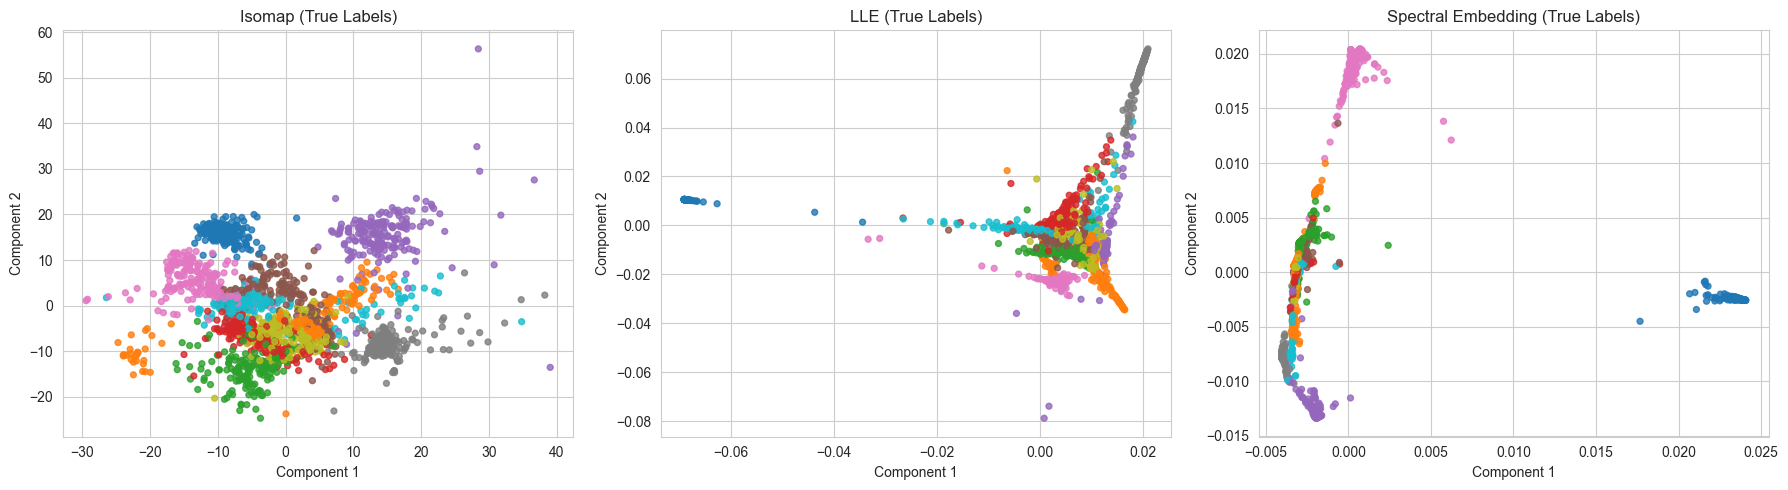

/Users/guywinfield/PycharmProjects/.turing_venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


           Projection           Clustering  Silhouette Score       ARI
0              Isomap              K-Means          0.458576  0.524809
1              Isomap  Spectral Clustering          0.409760  0.500203
2                 LLE              K-Means          0.571001  0.381611
3                 LLE  Spectral Clustering          0.355850  0.359006
4  Spectral Embedding              K-Means          0.627801  0.493935
5  Spectral Embedding  Spectral Clustering          0.484734  0.470748


/Users/guywinfield/PycharmProjects/.turing_venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


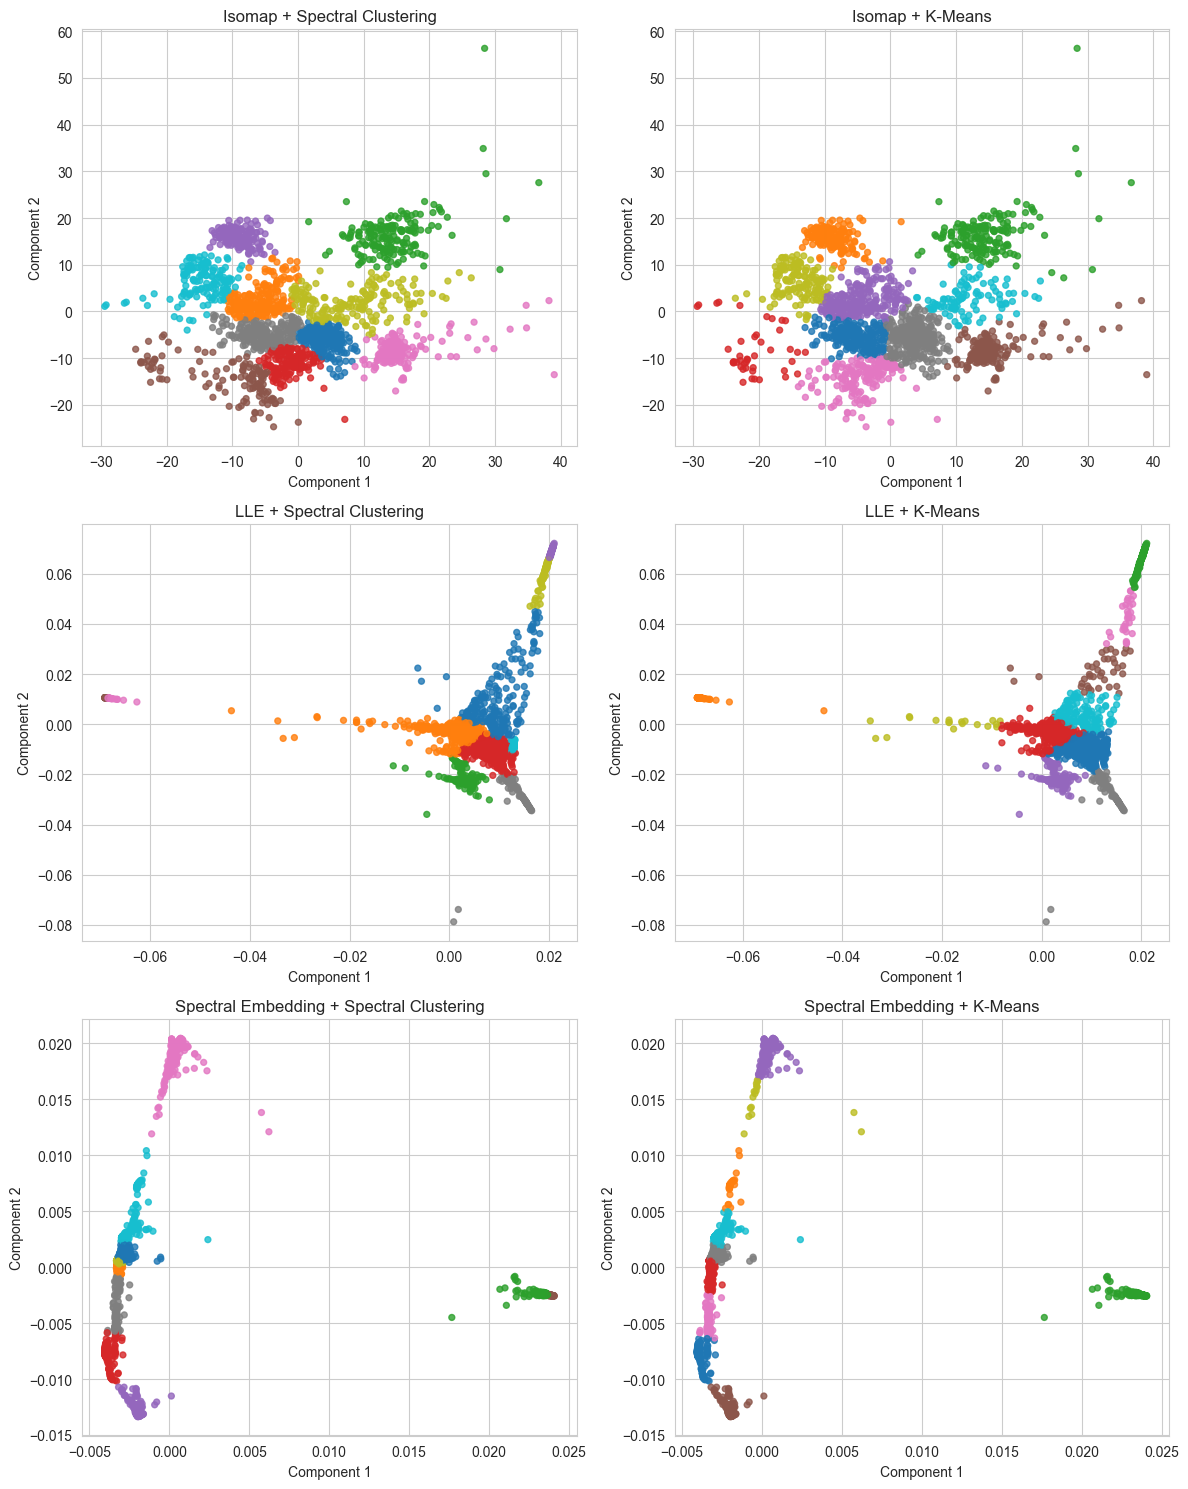


Summary table:
                   Silhouette Score                           ARI  \
Clustering                  K-Means Spectral Clustering   K-Means   
Projection                                                          
Isomap                     0.458576            0.409760  0.524809   
LLE                        0.571001            0.355850  0.381611   
Spectral Embedding         0.627801            0.484734  0.493935   

                                        
Clustering         Spectral Clustering  
Projection                              
Isomap                        0.500203  
LLE                           0.359006  
Spectral Embedding            0.470748  


In [10]:
# =========================
# 1. Imports
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import Isomap, LocallyLinearEmbedding, SpectralEmbedding
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score


# =========================
# 2. Load and preprocess the dataset
# =========================
digits = load_digits()
X = digits.data
y = digits.target

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique classes:", np.unique(y))

# Standardize features
# Important because manifold methods and clustering are distance-based
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# =========================
# 3. Create 2D manifold projections
# =========================
random_state = 42

manifold_methods = {
    "Isomap": Isomap(n_neighbors=10, n_components=2),
    "LLE": LocallyLinearEmbedding(n_neighbors=10, n_components=2, method="standard"),
    "Spectral Embedding": SpectralEmbedding(
        n_components=2,
        n_neighbors=10,
        random_state=random_state
    )
}

embeddings = {}

for name, model in manifold_methods.items():
    X_2d = model.fit_transform(X_scaled)
    embeddings[name] = X_2d
    print(f"{name} embedding shape: {X_2d.shape}")


# =========================
# 4. Visualize 2D projections with true labels
# =========================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, X_2d) in zip(axes, embeddings.items()):
    scatter = ax.scatter(
        X_2d[:, 0],
        X_2d[:, 1],
        c=y,
        cmap="tab10",
        s=18,
        alpha=0.8
    )
    ax.set_title(f"{name} (True Labels)")
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

plt.tight_layout()
plt.show()


# =========================
# 5. Clustering on each 2D projection
#    - Spectral Clustering
#    - K-Means
# =========================
results = []

for name, X_2d in embeddings.items():
    # ---- Spectral Clustering ----
    spectral = SpectralClustering(
        n_clusters=10,
        affinity="nearest_neighbors",
        n_neighbors=10,
        assign_labels="kmeans",
        random_state=random_state
    )
    spectral_labels = spectral.fit_predict(X_2d)

    spectral_sil = silhouette_score(X_2d, spectral_labels)
    spectral_ari = adjusted_rand_score(y, spectral_labels)

    results.append({
        "Projection": name,
        "Clustering": "Spectral Clustering",
        "Silhouette Score": spectral_sil,
        "ARI": spectral_ari
    })

    # ---- K-Means ----
    kmeans = KMeans(n_clusters=10, random_state=random_state, n_init=10)
    kmeans_labels = kmeans.fit_predict(X_2d)

    kmeans_sil = silhouette_score(X_2d, kmeans_labels)
    kmeans_ari = adjusted_rand_score(y, kmeans_labels)

    results.append({
        "Projection": name,
        "Clustering": "K-Means",
        "Silhouette Score": kmeans_sil,
        "ARI": kmeans_ari
    })


# =========================
# 6. Results table
# =========================
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(["Projection", "Clustering"]).reset_index(drop=True)

print(results_df)


# =========================
# 7. Visualize clustering assignments
# =========================
fig, axes = plt.subplots(len(embeddings), 2, figsize=(12, 15))

for row_idx, (name, X_2d) in enumerate(embeddings.items()):
    # Spectral clustering
    spectral = SpectralClustering(
        n_clusters=10,
        affinity="nearest_neighbors",
        n_neighbors=10,
        assign_labels="kmeans",
        random_state=random_state
    )
    spectral_labels = spectral.fit_predict(X_2d)

    axes[row_idx, 0].scatter(
        X_2d[:, 0],
        X_2d[:, 1],
        c=spectral_labels,
        cmap="tab10",
        s=18,
        alpha=0.8
    )
    axes[row_idx, 0].set_title(f"{name} + Spectral Clustering")
    axes[row_idx, 0].set_xlabel("Component 1")
    axes[row_idx, 0].set_ylabel("Component 2")

    # KMeans
    kmeans = KMeans(n_clusters=10, random_state=random_state, n_init=10)
    kmeans_labels = kmeans.fit_predict(X_2d)

    axes[row_idx, 1].scatter(
        X_2d[:, 0],
        X_2d[:, 1],
        c=kmeans_labels,
        cmap="tab10",
        s=18,
        alpha=0.8
    )
    axes[row_idx, 1].set_title(f"{name} + K-Means")
    axes[row_idx, 1].set_xlabel("Component 1")
    axes[row_idx, 1].set_ylabel("Component 2")

plt.tight_layout()
plt.show()


# =========================
# 8. Optional: nicer summary table
# =========================
summary_table = results_df.pivot(
    index="Projection",
    columns="Clustering",
    values=["Silhouette Score", "ARI"]
)

print("\nSummary table:")
print(summary_table)

# Graph based unsupervised learning


Graph-based methods represent data as nodes in a graph, where edges reflect relationships, similarity, or proximity between items. These approaches are particularly powerful when the data has an inherent relational structure—like social networks, citation networks, or item co-occurrence graphs. In unsupervised learning, graphs are used for clustering (community detection), dimensionality reduction (via graph Laplacians), and feature learning (though this techniques require understanding of deep learning, so will not be explained in this part).

### Constructing a Similarity Graph from Data

Many tabular datasets can be transformed into graphs by connecting each point to its k-nearest neighbors, turning them into similarity graphs. This graph can then be used for methods like Spectral Clustering or community detection. Example:

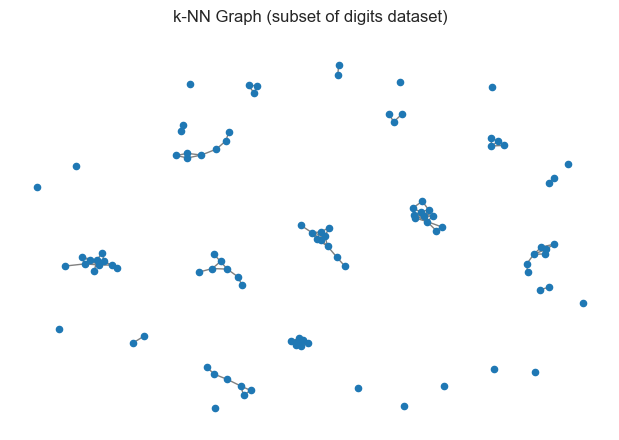

In [15]:
from sklearn.datasets import load_digits
from sklearn.neighbors import kneighbors_graph
import networkx as nx
import matplotlib.pyplot as plt

digits = load_digits()
X = digits.data
y = digits.target

A = kneighbors_graph(X, n_neighbors=10, include_self=False)
G = nx.from_scipy_sparse_array(A)

plt.figure(figsize=(6, 4))
subgraph = G.subgraph(range(100))
nx.draw_spring(subgraph, node_size=20, edge_color='gray')
plt.title("k-NN Graph (subset of digits dataset)")
plt.show()

This graph shows how points are connected based on local similarity. Although visualizing high-dimensional data directly is difficult, these graphs are internally used in manifold learning (e.g., Isomap, Spectral Embedding) and spectral clustering.

### Community Detection via Louvain Algorithm

Community detection aims to identify densely connected subgraphs (clusters) without specifying the number of clusters in advance. The Louvain method is a popular algorithm for this purpose and is commonly used in social network analysis.

In [18]:
!pip install python-louvain

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for python-louvain: filename=python_louvain-0.16-py3-none-any.whl size=9459 sha256=eaadf4023162e860e73797c5875802461b2f0aff604f1c4192bd5bbb238dd61b
  Stored in directory: /Users/guywinfield/Library/Caches/pip/wheels/ee/52/54/7ecd0f1ebf5f5a8466f70a27ed2b94d20b955376879d6159c5
Successfully built python-louvain

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


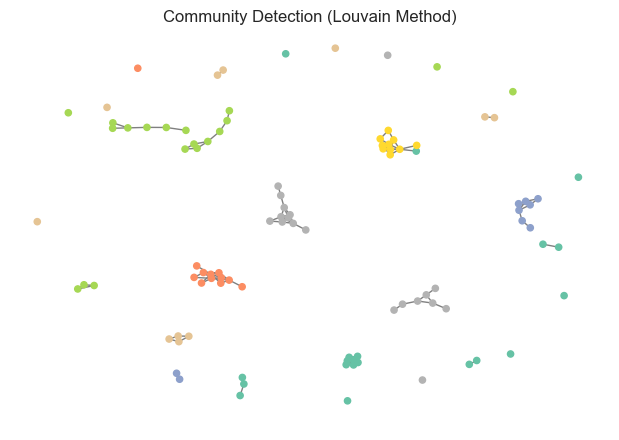

In [19]:

import community as community_louvain

partition = community_louvain.best_partition(G)

labels = list(partition.values())

plt.figure(figsize=(6, 4))
nx.draw_spring(subgraph, node_color=[labels[i] for i in subgraph.nodes()],
            node_size=20, cmap='Set2', edge_color='gray')
plt.title("Community Detection (Louvain Method)")
plt.show()

### Graph Laplacians for Spectral Clustering

Graph-based clustering can also be done using the graph Laplacian, a matrix that encodes the structure of the graph. This is the core behind spectral clustering, which we already discussed earlier. The Laplacian's eigenvectors capture smooth global structure over the graph.

You can compute the Laplacian manually using scipy:

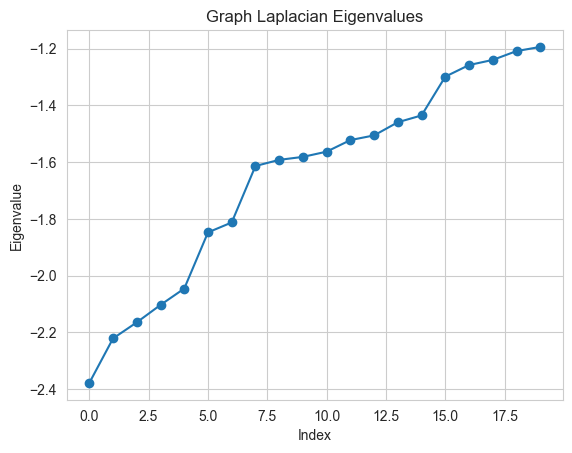

In [21]:
from scipy.sparse.csgraph import laplacian
import numpy as np

L = laplacian(A, normed=False)
eigenvalues, eigenvectors = np.linalg.eigh(L.toarray())

plt.plot(eigenvalues[:20], marker='o')
plt.title("Graph Laplacian Eigenvalues")
plt.xlabel("Index")
plt.ylabel("Eigenvalue")
plt.grid(True)
plt.show()

Gaps in the eigenvalue spectrum can hint at the number of clusters. This method forms the basis of spectral clustering: using the first k eigenvectors of the Laplacian as features and clustering them using K-Means.

### Summarization:


Clustering Digits via Graph-Based Approach Y ou can now apply Spectral Clustering directly using the similarity graph built earlier:

In [24]:
from sklearn.cluster import SpectralClustering
from sklearn.metrics import adjusted_rand_score

sc = SpectralClustering(n_clusters=10, affinity='precomputed', random_state=0)
labels_sc = sc.fit_predict(A.toarray())

print("Adjusted Rand Index (Graph-based Clustering):",
      adjusted_rand_score(y, labels_sc))

/Users/guywinfield/PycharmProjects/.turing_venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:309: UserWarning: Array is not symmetric, and will be converted to symmetric by average with its transpose.
  adjacency = check_symmetric(adjacency)


Adjusted Rand Index (Graph-based Clustering): 0.7579782999526471


This result shows how graph structure alone can reveal meaningful clusters. You can try the same workflow on citation networks, product co-purchases, or social interactions—where edge structure holds more information than features.

## Anomaly detection

Anomaly detection is a core task in unsupervised learning that focuses on identifying rare or unusual patterns in data that deviate significantly from the norm. Unlike traditional classification or clustering, anomaly detection assumes that the training data is mostly composed of "normal" instances and that anomalies are statistically distinct. These techniques are especially important in domains where labeled data is scarce or anomalies are too rare to appear in sufficient quantity during training — such as fraud detection, equipment failure, cybersecurity breaches, and medical diagnostics.

There are several types of anomalies: point anomalies (individual data points that are rare), contextual anomalies (normal in one context, anomalous in another, like high temperature in winter), and collective anomalies (a sequence of values that is anomalous together). Classical approaches include statistical methods (e.g., z-scores, Gaussian mixture models), distance-based methods (e.g., k-NN or DBSCAN), and density-based methods such as Isolation Forests and Local Outlier Factor (LOF). These do not require labeled data and assume that anomalies occur in sparse, low-density regions of the feature space.

A popular algorithm is the Isolation Forest, which isolates anomalies by randomly partitioning the feature space. Because anomalies are few and different, they tend to be isolated early in the partitioning process. Another approach is the Local Outlier Factor, which compares the local density of each point to that of its neighbors; a significantly lower density is interpreted as an outlier. These methods work well on high-dimensional data and scale to large datasets, making them suitable for real-time monitoring systems.

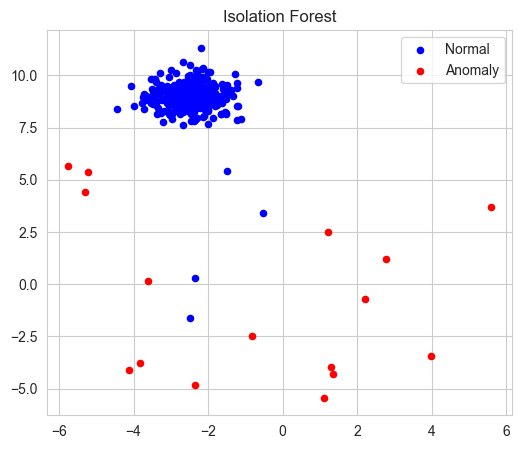

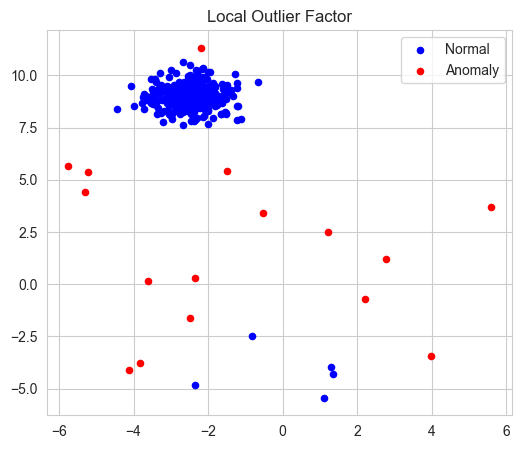

In [27]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

X, _ = make_blobs(n_samples=300, centers=1, cluster_std=0.60, random_state=42)
rng = np.random.RandomState(42)
outliers = rng.uniform(low=-6, high=6, size=(20, 2))
X_full = np.vstack([X, outliers])

iso = IsolationForest(contamination=0.05, random_state=42)
y_pred_iso = iso.fit_predict(X_full)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
y_pred_lof = lof.fit_predict(X_full)

def plot_anomalies(X, y_pred, title):
    plt.figure(figsize=(6, 5))
    plt.scatter(X[y_pred == 1][:, 0], X[y_pred == 1][:, 1], c='blue',
						    s=20, label='Normal')
    plt.scatter(X[y_pred == -1][:, 0], X[y_pred == -1][:, 1], c='red',
						    s=20, label='Anomaly')
    plt.legend()
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_anomalies(X_full, y_pred_iso, "Isolation Forest")
plot_anomalies(X_full, y_pred_lof, "Local Outlier Factor")

Anomaly detection techniques are highly sensitive to assumptions about data distribution and density, so careful tuning of parameters (like contamination, n_neighbors, etc.) is essential. Additionally, evaluating performance is tricky in the absence of labels — common metrics include precision-recall, ROC-AUC (if labels are available), or visual inspection in low dimensions. For unsupervised problems in critical systems, anomaly detection plays a vital role in proactively identifying risks and preventing failures before they escalate.

Shape of full dataset: (315, 2)
Number of nodes: 315
Number of edges: 2004
Number of communities found: 10


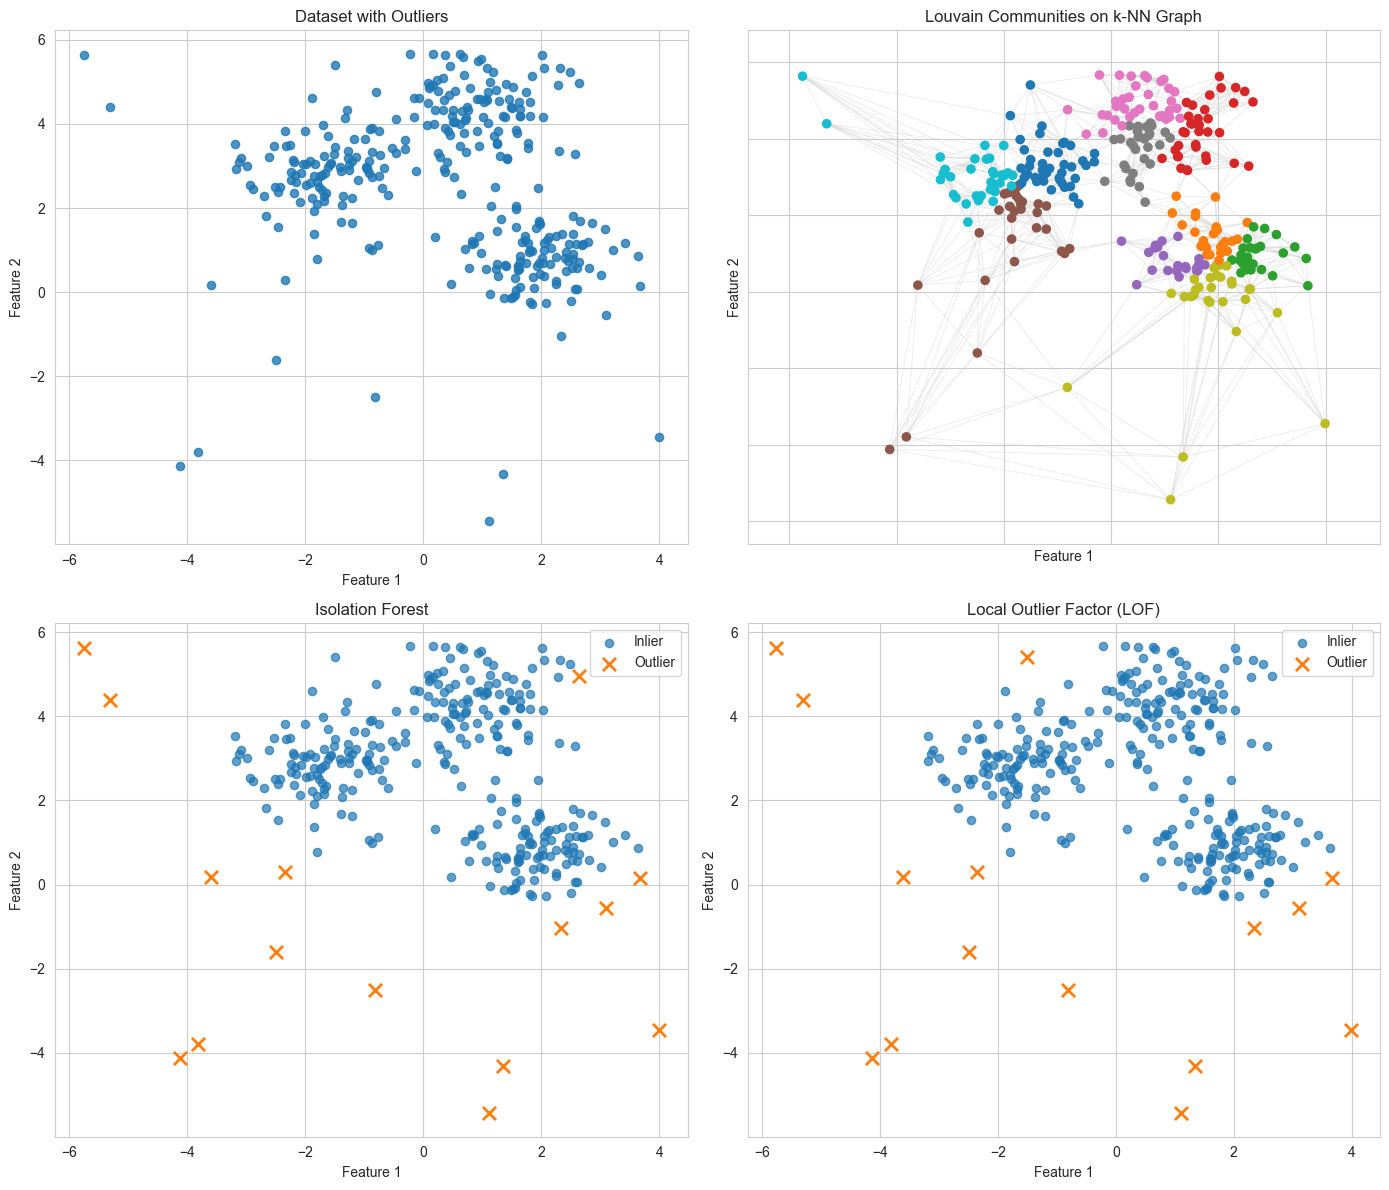

Isolation Forest outliers detected: 15
LOF outliers detected: 15


In [29]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.datasets import make_blobs
from sklearn.neighbors import kneighbors_graph, LocalOutlierFactor
from sklearn.ensemble import IsolationForest

# =========================
# 1. Create dataset with outliers
# =========================
X, _ = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=0.7,
    random_state=0
)

rng = np.random.RandomState(42)
outliers = rng.uniform(low=-6, high=6, size=(15, 2))

X_full = np.vstack([X, outliers])

print("Shape of full dataset:", X_full.shape)


# =========================
# 2. Build k-NN graph
# =========================
n_neighbors = 10

A = kneighbors_graph(
    X_full,
    n_neighbors=n_neighbors,
    mode="connectivity",
    include_self=False
)

# For newer versions of networkx
G = nx.from_scipy_sparse_array(A)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())


# =========================
# 3. Louvain community detection
# =========================
# This requires a reasonably recent version of networkx
# If this errors, update networkx or use python-louvain package
communities = nx.community.louvain_communities(G, seed=42)

# Convert community sets into a label array
community_labels = np.full(X_full.shape[0], -1)

for community_id, community_nodes in enumerate(communities):
    for node in community_nodes:
        community_labels[node] = community_id

print("Number of communities found:", len(communities))


# =========================
# 4. Anomaly Detection
# =========================

# ---- Isolation Forest ----
iso = IsolationForest(
    contamination=15 / len(X_full),   # roughly matches true outlier count
    random_state=42
)
iso_pred = iso.fit_predict(X_full)   # -1 = outlier, 1 = inlier
iso_scores = iso.decision_function(X_full)

# ---- Local Outlier Factor ----
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=15 / len(X_full)
)
lof_pred = lof.fit_predict(X_full)   # -1 = outlier, 1 = inlier
lof_scores = lof.negative_outlier_factor_


# =========================
# 5. Visualize all results
# =========================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# ---------------------------------
# Plot 1: Raw dataset
# ---------------------------------
axes[0, 0].scatter(X_full[:, 0], X_full[:, 1], s=35, alpha=0.8)
axes[0, 0].set_title("Dataset with Outliers")
axes[0, 0].set_xlabel("Feature 1")
axes[0, 0].set_ylabel("Feature 2")


# ---------------------------------
# Plot 2: k-NN graph + Louvain communities
# ---------------------------------
pos = {i: X_full[i] for i in range(len(X_full))}

nx.draw_networkx_edges(
    G,
    pos=pos,
    ax=axes[0, 1],
    edge_color="lightgray",
    alpha=0.4,
    width=0.7
)

scatter = axes[0, 1].scatter(
    X_full[:, 0],
    X_full[:, 1],
    c=community_labels,
    cmap="tab10",
    s=35
)

axes[0, 1].set_title("Louvain Communities on k-NN Graph")
axes[0, 1].set_xlabel("Feature 1")
axes[0, 1].set_ylabel("Feature 2")


# ---------------------------------
# Plot 3: Isolation Forest
# ---------------------------------
inliers_iso = iso_pred == 1
outliers_iso = iso_pred == -1

axes[1, 0].scatter(
    X_full[inliers_iso, 0],
    X_full[inliers_iso, 1],
    s=35,
    alpha=0.7,
    label="Inlier"
)

axes[1, 0].scatter(
    X_full[outliers_iso, 0],
    X_full[outliers_iso, 1],
    s=90,
    marker="x",
    linewidths=2,
    label="Outlier"
)

axes[1, 0].set_title("Isolation Forest")
axes[1, 0].set_xlabel("Feature 1")
axes[1, 0].set_ylabel("Feature 2")
axes[1, 0].legend()


# ---------------------------------
# Plot 4: Local Outlier Factor
# ---------------------------------
inliers_lof = lof_pred == 1
outliers_lof = lof_pred == -1

axes[1, 1].scatter(
    X_full[inliers_lof, 0],
    X_full[inliers_lof, 1],
    s=35,
    alpha=0.7,
    label="Inlier"
)

axes[1, 1].scatter(
    X_full[outliers_lof, 0],
    X_full[outliers_lof, 1],
    s=90,
    marker="x",
    linewidths=2,
    label="Outlier"
)

axes[1, 1].set_title("Local Outlier Factor (LOF)")
axes[1, 1].set_xlabel("Feature 1")
axes[1, 1].set_ylabel("Feature 2")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


# =========================
# 6. Optional: print anomaly counts
# =========================
print("Isolation Forest outliers detected:", np.sum(iso_pred == -1))
print("LOF outliers detected:", np.sum(lof_pred == -1))